## Regresion lineal multiple

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import seaborn as sns


In [3]:
dataP = sns.load_dataset("penguins")
dataP

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [4]:
dataP.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [5]:
dataP.shape

(344, 7)

In [6]:
print(dataP.isnull().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


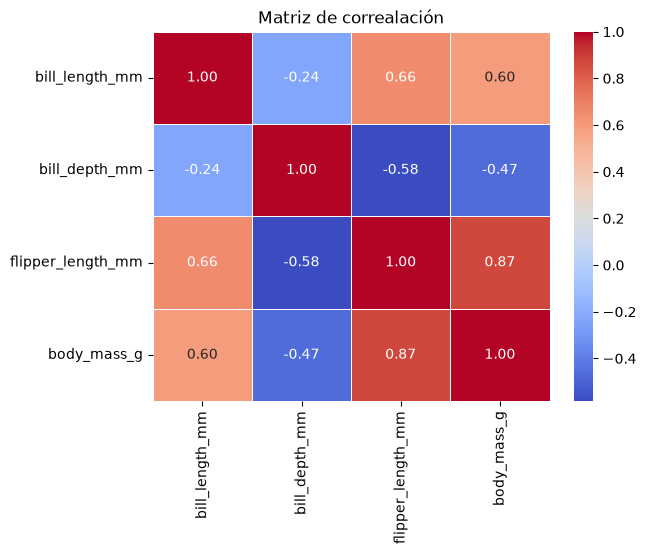

In [7]:
# Matriz de correlacion

corr_matriz = dataP.corr(numeric_only=True)

sns.heatmap(corr_matriz, annot= True, cmap = "coolwarm", fmt=".2f", linewidths= 0.5)
plt.title("Matriz de correalación")
plt.show()


In [8]:
dataP = dataP.dropna()

x = dataP[["bill_length_mm", "flipper_length_mm"]]
y = dataP["body_mass_g"]

# 70% entrenamiento
# 30% prueba

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.3, random_state= 42)



In [9]:
model = LinearRegression()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)
r2 = r2_score(y_test, y_predict)
rms = mean_squared_error(y_test, y_predict)**(1/2)

In [10]:
print("Coeficientes del modelo : ", model.coef_)
print("Intercepto : ", model.intercept_)
print(f"r2 del modelo :  {r2:.2f}")
print(f"Error cuadratico medio : {rms:.2f}")

Coeficientes del modelo :  [ 6.13328924 49.72977466]
Intercepto :  -6068.42585873859
r2 del modelo :  0.77
Error cuadratico medio : 372.81


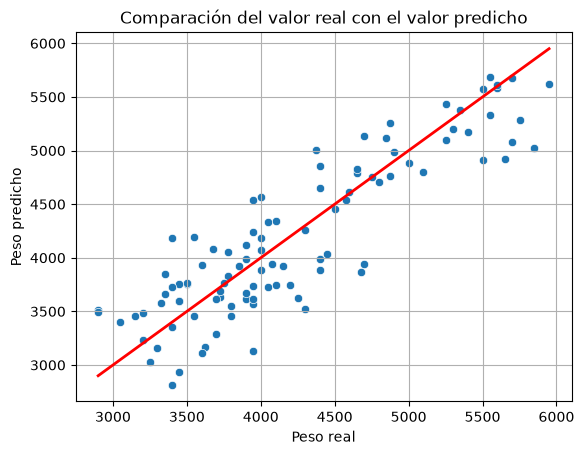

In [12]:
sns.scatterplot(x = y_test, y = y_predict)
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, color = "red", linewidth = 2 )
plt.xlabel("Peso real")
plt.ylabel("Peso predicho")
plt.title("Comparación del valor real con el valor predicho")
plt.grid()
plt.show()

